# Week 1 EDA: DepMap, TCGA-BRCA, GTEx

Basic exploratory data analysis on the three downloaded raw data sources --
dimensions, missingness, and value distributions -- per the Week 1 checklist
in `NOTES.md`. The biological "why this dataset" reasoning lives in
`NOTES.md`; this notebook is just the numbers behind that reasoning.

All loading goes through `src/data_utils.py` so this notebook and any future
analysis notebook load data identically.


**Inputs:** `data/raw/depmap/`, `data/raw/tcga/`, `data/raw/gtex/` (the README's Setup section covers how each is downloaded).  
**Outputs:** none. This notebook only inspects the data.  
**Run order:** first; run it before `02_selective_essentiality.ipynb`.

In [1]:
# Load all three raw data sources via data_utils, and print the release/run identifiers
import sys
sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from data_utils import (
    load_model_metadata, load_gene_effect, get_tnbc_model_ids,
    load_tcga_expression, load_tcga_clinical_cdes, get_tnbc_patient_barcodes,
    tcga_patient_barcode, tcga_is_tumor_sample,
    load_gtex_median_tpm,
    DEPMAP_RELEASE, TCGA_RUN, GTEX_RELEASE,
)

print("DepMap release:", DEPMAP_RELEASE)
print("TCGA run:", TCGA_RUN)
print("GTEx release:", GTEX_RELEASE)


DepMap release: 26Q1
TCGA run: GDAC Firehose stddata__2016_01_28 (BRCA)
GTEx release: v11


## DepMap: CRISPR gene-effect matrix (Chronos scores)

Cell lines x genes. A more negative score means knocking out that gene hurt
that cell line's growth/viability more -- i.e. the cell line depends on it
more.


In [2]:
# Check the gene-effect matrix's shape and how much of it is missing, and where the missingness concentrates
effect = load_gene_effect()
print("Shape (cell lines x genes):", effect.shape)

n_missing = effect.isna().sum().sum()
print(f"Missing values: {n_missing:,} of {effect.size:,} ({n_missing / effect.size:.2%})")
print("Cell lines with at least one missing gene:", (effect.isna().sum(axis=1) > 0).sum(), "of", effect.shape[0])
print("Genes missing in at least one cell line:", (effect.isna().sum(axis=0) > 0).sum(), "of", effect.shape[1])


Shape (cell lines x genes): (1208, 18531)
Missing values: 887,151 of 22,385,448 (3.96%)
Cell lines with at least one missing gene: 1208 of 1208
Genes missing in at least one cell line: 1444 of 18531


Every cell line has *some* missing genes, but only ~8% of genes are missing
in any cell line at all -- consistent with a handful of genes being
inconsistently screened/QC-filtered across the panel, not a systematic
problem with the matrix. Missing values are left as NaN by `load_gene_effect`
and handled at analysis time (e.g. pairwise `dropna` when comparing TNBC vs.
other cell lines in Week 2), not imputed here.


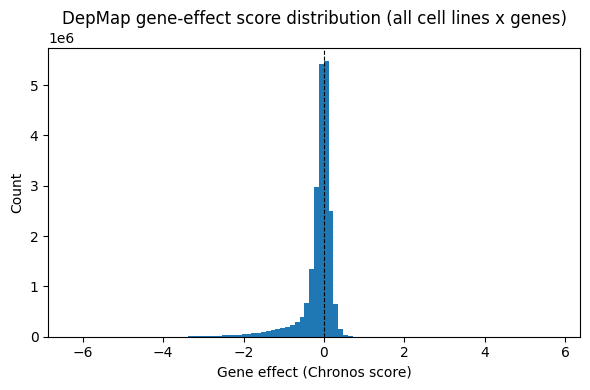

min=-6.258  max=5.769  mean=-0.149  median=-0.042  std=0.434


In [3]:
# Flatten all gene-effect scores into one distribution and plot it
vals = effect.values.flatten()
vals = vals[~np.isnan(vals)]

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(vals, bins=100)
ax.set_xlabel("Gene effect (Chronos score)")
ax.set_ylabel("Count")
ax.set_title("DepMap gene-effect score distribution (all cell lines x genes)")
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
plt.tight_layout()
plt.show()

print(f"min={vals.min():.3f}  max={vals.max():.3f}  mean={vals.mean():.3f}  median={np.median(vals):.3f}  std={vals.std():.3f}")


The distribution is centered just below 0 and unimodal, as expected: most
gene knockouts have little to no effect on a given cell line's growth, and
only a minority of genes (the left tail, strongly negative) are meaningfully
essential. This is the expected shape for a genome-wide CRISPR screen and
matches published DepMap distributions.


In [4]:
# Cross-check the Week 1 TNBC cell-line list against which lines actually have CRISPR data
model = load_model_metadata()
tnbc_ids = get_tnbc_model_ids(model)
tnbc_in_effect = effect.index.intersection(tnbc_ids)
print(f"TNBC cell lines with CRISPR data: {len(tnbc_in_effect)} of {len(tnbc_ids)} labeled TNBC lines")


TNBC cell lines with CRISPR data: 25 of 34 labeled TNBC lines


25 of the 34 TNBC-labeled cell lines have a row in the CRISPR matrix. The other 9 were not screened in this release, so the TNBC comparison group in Week 2 is 25 lines, not 34.

## TCGA-BRCA: RSEM-normalized expression matrix

Genes x samples (most samples are primary tumor; a smaller set are normal/
other sample types -- see the sample-type breakdown below).


In [5]:
# Check the TCGA expression matrix's shape, missingness, and sample-type breakdown (tumor vs. normal)
expr = load_tcga_expression()
print("Shape (genes x samples):", expr.shape)

n_missing = expr.isna().sum().sum()
print(f"Missing values: {n_missing:,} of {expr.size:,}")

sample_types = pd.Series([c.split("-")[3] for c in expr.columns]).value_counts()
print("\nSample-type codes (01=primary tumor, 11=solid normal, etc.):")
print(sample_types)


Shape (genes x samples): (20531, 1212)
Missing values: 0 of 24,883,572

Sample-type codes (01=primary tumor, 11=solid normal, etc.):
01A    1080
11A      98
11B      14
01B      13
06A       7
Name: count, dtype: int64


No missing values at all -- RSEM's normalization step produces a dense
matrix by construction (every gene gets an estimate for every sample, even a
near-zero one), unlike DepMap's screen-dependent missingness above.

Sample-type code `01A` (primary tumor) dominates, with a much smaller set of
matched-normal (`11A`) and other codes -- this is the real number behind the
still-open "matched TCGA normal vs. GTEx baseline" decision in `CLAUDE.md`.


Fraction of values exactly 0: 14.28%


min=0.000  max=2,066,039.2  mean=935.778  median=194.375


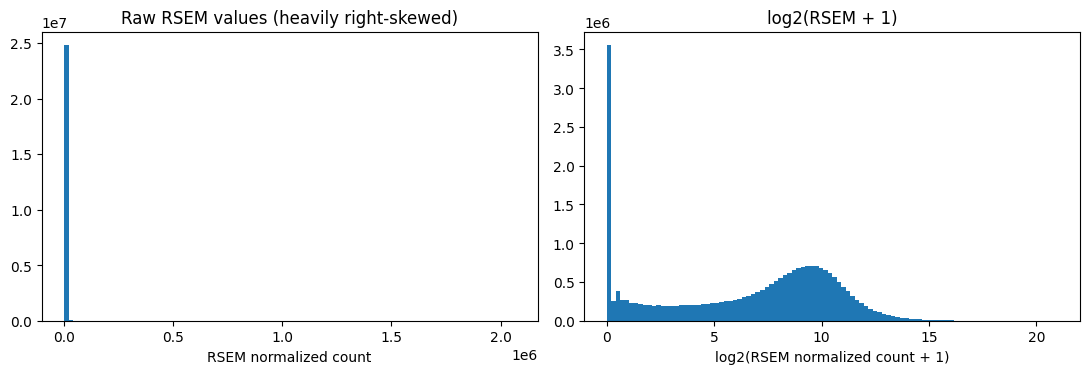

In [6]:
# Compare raw vs. log2-transformed expression value distributions, then flag the single most extreme value
evals = expr.values.flatten().astype(float)
zero_frac = (evals == 0).mean()
print(f"Fraction of values exactly 0: {zero_frac:.2%}")
print(f"min={np.nanmin(evals):.3f}  max={np.nanmax(evals):,.1f}  mean={np.nanmean(evals):.3f}  median={np.nanmedian(evals):.3f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(evals, bins=100)
axes[0].set_title("Raw RSEM values (heavily right-skewed)")
axes[0].set_xlabel("RSEM normalized count")

log_vals = np.log2(evals + 1)
axes[1].hist(log_vals, bins=100)
axes[1].set_title("log2(RSEM + 1)")
axes[1].set_xlabel("log2(RSEM normalized count + 1)")
plt.tight_layout()
plt.show()


Raw RSEM values are, as expected for RNA-seq counts, extremely right-skewed
-- most gene/sample combinations are low or zero, with a long tail of highly
expressed genes. `log2(x + 1)` is the standard transform for this kind of
data and gives a far more usable, roughly unimodal distribution -- this is
the transform planned for Week 2/3's expression comparisons, same reasoning
as the ADMET project's logS transform for solubility (multiplicative scale ->
additive scale).

The single most extreme raw value (~2,066,039, briefly investigated to rule
out a parsing bug) belongs to **SCGB2A2** (mammaglobin-B) in one sample --
mammaglobin is a well-known, extremely breast-tissue-specific secreted
protein and a classic breast cancer marker, so an extreme value for it in
one tumor sample is real biology, not a data error. The genes with the
highest *median* expression across all samples (`COL1A1`, `ACTB`, `EEF1A1`,
`COL1A2`, `FN1`, ...) are exactly the housekeeping/structural genes (actin,
translation factors) and stromal/collagen genes expected to dominate bulk
tissue RNA-seq -- another sanity check that this matrix is behaving as real
expression data should.


In [7]:
# Count how many TNBC patients actually have a matched primary-tumor expression sample
cde = load_tcga_clinical_cdes()
tnbc_patients = set(get_tnbc_patient_barcodes(cde))
tumor_samples = [c for c in expr.columns if tcga_is_tumor_sample(c)]
tnbc_tumor_samples = [c for c in tumor_samples if tcga_patient_barcode(c) in tnbc_patients]
print(f"Primary tumor samples: {len(tumor_samples)}")
print(f"TNBC primary tumor samples with expression data: {len(tnbc_tumor_samples)}")


Primary tumor samples: 1093
TNBC primary tumor samples with expression data: 142


142 of the 143 TNBC patients have a matched primary-tumor expression sample. Those 142 are the patients used for the survival analysis in Week 4.

## TCGA-BRCA: clinical data (receptor status + survival)


In [8]:
# Build a missingness table for the clinical fields the TNBC definition and survival analysis depend on
print("Shape (attributes x patients):", cde.shape)

key_fields = [
    "breast_carcinoma_estrogen_receptor_status",
    "breast_carcinoma_progesterone_receptor_status",
    "lab_proc_her2_neu_immunohistochemistry_receptor_status",
    "lab_procedure_her2_neu_in_situ_hybrid_outcome_type",
    "vital_status",
    "days_to_death",
    "days_to_last_followup",
]
missing_counts = {}
for field in key_fields:
    row = cde.loc[field]
    missing_counts[field] = int((row.isna() | (row.astype(str).str.upper() == "NA")).sum())

pd.Series(missing_counts, name="missing_count").to_frame().assign(
    pct_missing=lambda d: (d["missing_count"] / cde.shape[1] * 100).round(1)
)


Shape (attributes x patients): (131, 1097)


,missing_count,pct_missing
breast_carcinoma_estrogen_receptor_status,49,4.5
breast_carcinoma_progesterone_receptor_status,50,4.6
lab_proc_her2_neu_immunohistochemistry_receptor_status,178,16.2
lab_procedure_her2_neu_in_situ_hybrid_outcome_type,677,61.7
vital_status,0,0.0
days_to_death,946,86.2
days_to_last_followup,152,13.9


ER/PR status is missing for only ~5% of patients, and HER2 IHC for ~16% --
reasonable completeness for the fields the TNBC definition depends on. HER2
FISH is missing for ~62%, but that's expected, not a data quality problem:
per the ASCO/CAP reflex rule (see `NOTES.md`/`data_utils.py`), FISH is only
run when the IHC result comes back equivocal (2+), so most patients simply
never needed a FISH test -- their HER2 status is already resolved by IHC
alone.

`days_to_death` missing for 946/1,097 (86%) and `days_to_last_followup`
missing for 152/1,097 (14%) look alarming individually but are two sides of
the same coin: a patient has *either* a days-to-death value (if they died)
*or* a days-to-last-followup value (if they didn't, as of last contact), not
both. `vital_status` (0% missing) is what actually determines which field
applies -- this is the standard shape of survival data and exactly what
Week 4's Kaplan-Meier/Cox analysis is built to consume, not a gap to fix.


## GTEx: median TPM by tissue


Shape (genes x [Description + tissues]): (74628, 69)
Missing values: 0
Fraction of values exactly 0: 54.19%
min=0.000  max=255,533.0  mean=12.573  median=0.000


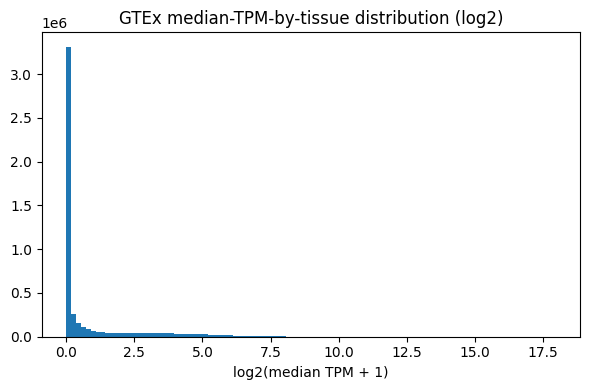

In [9]:
# Check the GTEx matrix's shape, missingness, and value distribution
gtex = load_gtex_median_tpm()
print("Shape (genes x [Description + tissues]):", gtex.shape)

gvals = gtex.drop(columns=["Description"]).values.flatten().astype(float)
n_missing = np.isnan(gvals).sum()
zero_frac = (gvals == 0).mean()
print(f"Missing values: {n_missing}")
print(f"Fraction of values exactly 0: {zero_frac:.2%}")
print(f"min={np.nanmin(gvals):.3f}  max={np.nanmax(gvals):,.1f}  mean={np.nanmean(gvals):.3f}  median={np.nanmedian(gvals):.3f}")

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(np.log2(gvals + 1), bins=100)
ax.set_xlabel("log2(median TPM + 1)")
ax.set_title("GTEx median-TPM-by-tissue distribution (log2)")
plt.tight_layout()
plt.show()


No missing values, and over half of all gene/tissue combinations are exactly
0 -- expected for tissue-specific expression data, where most genes are
simply not expressed (or expressed at negligible levels) in most tissues.
Same heavy right-skew as TCGA's expression data, and the same log2 transform
applies for any cross-tissue comparison in Week 3.


## Summary

| Dataset | Shape | Missingness | Notes |
|---|---|---|---|
| DepMap gene effect | 1,208 cell lines x 18,531 genes | 3.96% (concentrated in ~8% of genes) | Unimodal, centered ~0, long essential-gene tail |
| TCGA-BRCA expression | 20,531 genes x 1,212 samples | 0% | Heavily right-skewed; log2(x+1) planned |
| TCGA-BRCA clinical | 131 attributes x 1,097 patients | Field-dependent; explained per-field above | ER/PR/HER2 status + survival fields usable |
| GTEx median TPM | 74,628 genes x 68 tissues | 0% (54% exact zeros) | Heavily right-skewed; log2(x+1) planned |

This closes out Week 1's "record dimensions, missingness, and distributions"
item. Next: Week 2's selective-essentiality comparison (TNBC vs. other
DepMap cell lines).
